In [36]:
# WEEK 2 ASSIGNMENT - Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [8]:
df = df.dropna()

In [9]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")

df = df.sort_values("Date")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


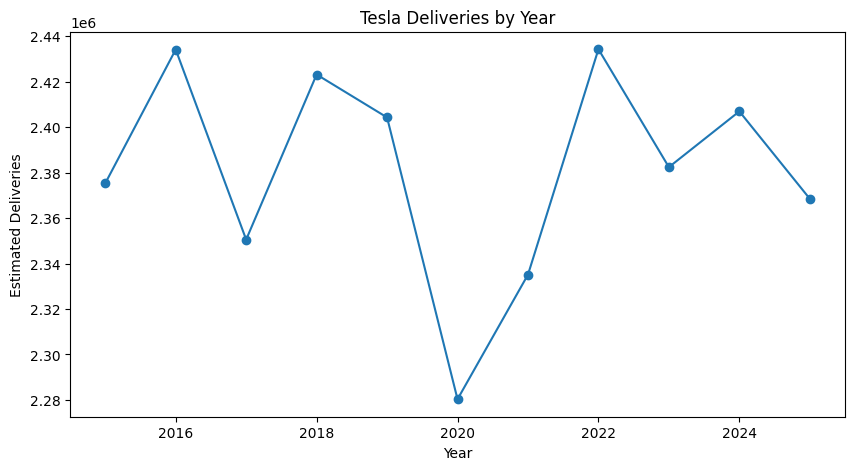

In [10]:
yearly_deliveries = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_deliveries.index, yearly_deliveries.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.title("Tesla Deliveries by Year")
plt.show()

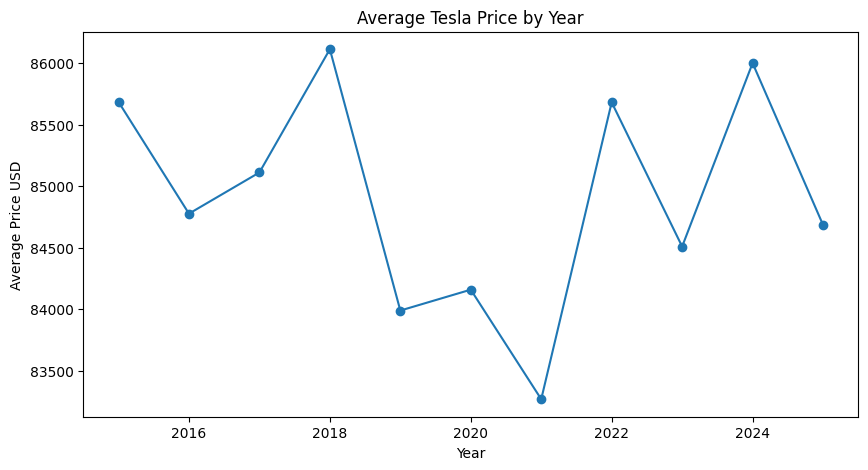

In [11]:
yearly_price = df.groupby("Year")["Avg_Price_USD"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_price.index, yearly_price.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average Price USD")
plt.title("Average Tesla Price by Year")
plt.show()

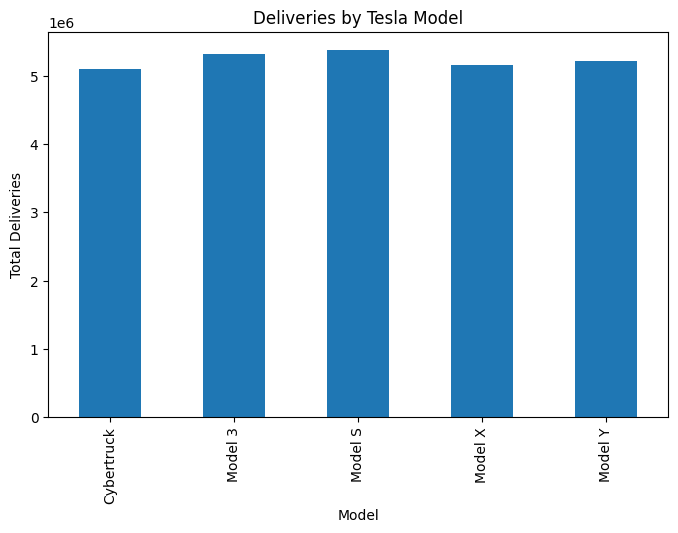

In [12]:
model_deliveries = df.groupby("Model")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))
model_deliveries.plot(kind="bar")
plt.xlabel("Model")
plt.ylabel("Total Deliveries")
plt.title("Deliveries by Tesla Model")
plt.show()

In [13]:
df_model = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_model["Region"] = le_region.fit_transform(df_model["Region"])
df_model["Model"] = le_model.fit_transform(df_model["Model"])
df_model["Source_Type"] = le_source.fit_transform(df_model["Source_Type"])

In [14]:
df_model["Production_Delivery_Ratio"] = df_model["Production_Units"] / df_model["Estimated_Deliveries"]
df_model["Price_per_km"] = df_model["Avg_Price_USD"] / df_model["Range_km"]

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(inplace=True)

In [15]:
#Regression model

#Target: predict Estimated_Deliveries.

In [16]:
X = df_model.drop(columns=["Estimated_Deliveries", "Date"])
y = df_model["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#Linear Regression

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 103.490971703563
RMSE: 152.25406278572177
R2 Score: 0.998452801093607


In [19]:
#Random Forest

In [20]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 63.03577651515151
RMSE: 129.23145822324994
R2 Score: 0.9988853337315377


In [32]:
### Model Comparison

# Random Forest achieved a higher R² score and lower error compared to Linear Regression, indicating better predictive performance.

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Production_Units             0.990402
Production_Delivery_Ratio    0.008665
CO2_Saved_tons               0.000126
Price_per_km                 0.000124
Avg_Price_USD                0.000108
Range_km                     0.000103
Charging_Stations            0.000103
Month                        0.000094
Year                         0.000078
Model                        0.000069
Region                       0.000068
Source_Type                  0.000038
Battery_Capacity_kWh         0.000022
dtype: float64


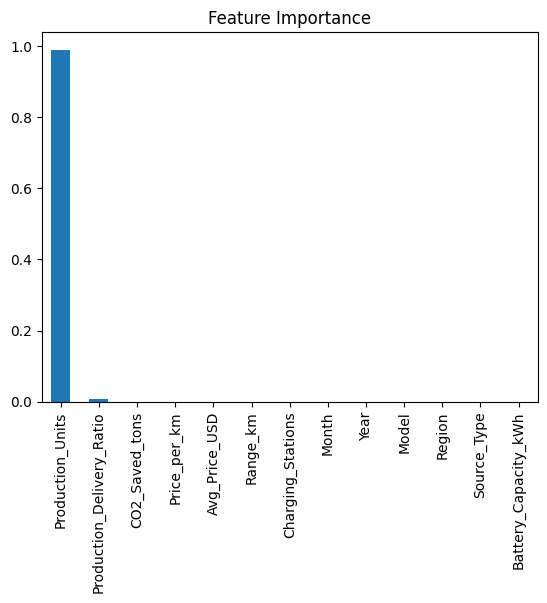

In [34]:
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [21]:
#Hyperparameter tuning

In [22]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9980352459542908


In [23]:
#Test Best Model

In [24]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score:", r2_score(y_test, y_pred_best))

Tuned Random Forest
MAE: 63.03577651515151
RMSE: 129.23145822324994
R2 Score: 0.9988853337315377


In [25]:
monthly_data = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

monthly_data.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


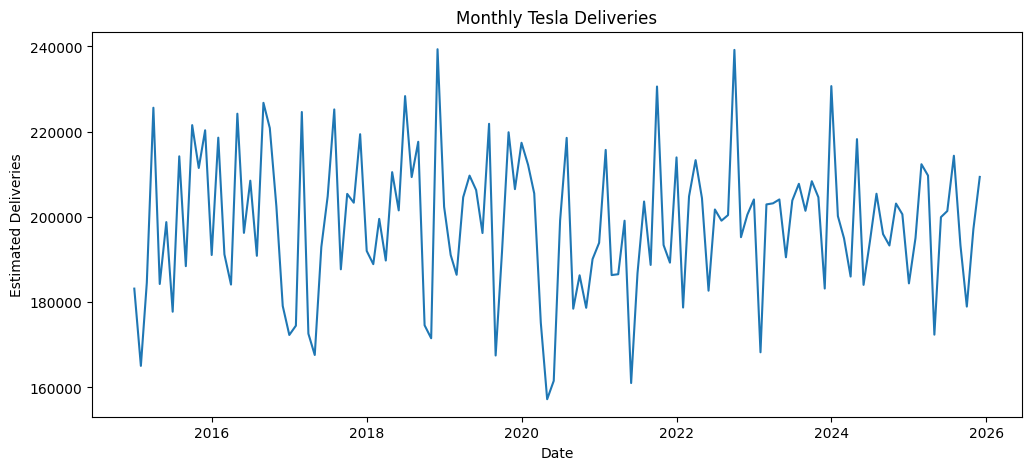

In [26]:
plt.figure(figsize=(12,5))
plt.plot(monthly_data["Date"], monthly_data["Estimated_Deliveries"])
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.title("Monthly Tesla Deliveries")
plt.show()

In [27]:
monthly_data["Time_Index"] = np.arange(len(monthly_data))

X_ts = monthly_data[["Time_Index"]]
y_ts = monthly_data["Estimated_Deliveries"]

In [28]:
ts_model = LinearRegression()
ts_model.fit(X_ts, y_ts)

LinearRegression()

In [29]:
future_index = np.arange(len(monthly_data), len(monthly_data) + 12).reshape(-1, 1)

future_predictions = ts_model.predict(future_index)

future_dates = pd.date_range(
    start=monthly_data["Date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Deliveries": future_predictions
})

forecast_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Predicted_Deliveries
0,2026-01-01,198436.571015
1,2026-02-01,198436.459415
2,2026-03-01,198436.347815
3,2026-04-01,198436.236215
4,2026-05-01,198436.124615
5,2026-06-01,198436.013015
6,2026-07-01,198435.901415
7,2026-08-01,198435.789815
8,2026-09-01,198435.678214
9,2026-10-01,198435.566614


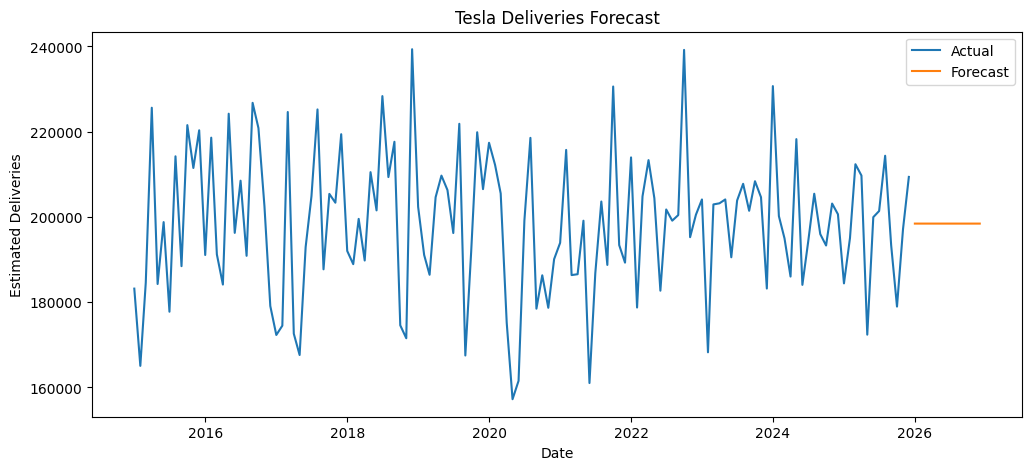

In [30]:
plt.figure(figsize=(12,5))
plt.plot(monthly_data["Date"], monthly_data["Estimated_Deliveries"], label="Actual")
plt.plot(forecast_df["Date"], forecast_df["Predicted_Deliveries"], label="Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.title("Tesla Deliveries Forecast")
plt.legend()
plt.show()

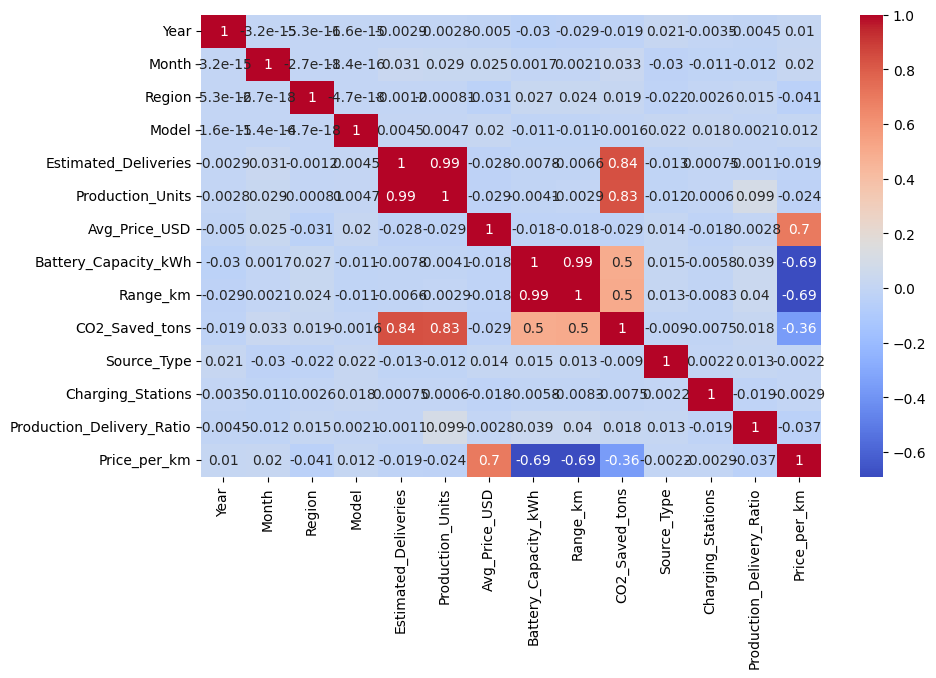

In [35]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df_model.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [31]:
# Conclusion

# In this assignment, an end-to-end machine learning pipeline was implemented using Tesla delivery and production data from 2015 to 2025. The workflow included data loading, preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

# Linear Regression and Random Forest Regressor were used to predict estimated deliveries. Random Forest performed better due to its ability to capture non-linear relationships between production units, price, battery capacity, range, charging stations, and deliveries.

# A simple time series forecasting model was also created to predict future monthly deliveries. This helped understand delivery trends over time./*